## waste management system

In [1]:
import zipfile
with zipfile.ZipFile("garbage_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("garbage_dataset")
print("✅ Extracted successfully!")

✅ Extracted successfully!


In [2]:
!pip install tensorflow keras numpy matplotlib opencv-python scikit-learn

In [3]:
import os
import numpy as np
import cv2

In [5]:
dataset_path = "garbage_dataset\garbage_classification"

# check available classes
categories = os.listdir(dataset_path)
print("Total Classes:", len(categories))
print("Categories:", categories)


Total Classes: 12
Categories: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## Load and preprocess images

In [6]:
data = []
labels = []

for i, category in enumerate(categories):
    folder = os.path.join(dataset_path, category)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        try:
            image = cv2.imread(img_path)
            image = cv2.resize(image, (128, 128))
            data.append(image)
            labels.append(i)
        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("✅ Data Loaded:", data.shape)
print("✅ Labels Loaded:", labels.shape)


✅ Data Loaded: (15515, 128, 128, 3)
✅ Labels Loaded: (15515,)


## Split data into train and test sets

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

data = data / 255.0  # normalization
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (12412, 128, 128, 3)
Test shape: (3103, 128, 128, 3)


## Transfer Learning Training

In [33]:
# 🔹 Transfer Learning Training Cell 

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1️⃣ Set image size and batch
img_size = (224,224)
batch_size = 32

# 2️⃣ Data generators with augmentation and validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% validation
)

train_generator = train_datagen.flow_from_directory(
    'garbage_dataset/garbage_classification',           # dataset folder path
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    'garbage_dataset/garbage_classification',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Save class names
categories = list(train_generator.class_indices.keys())
print("✅ Classes:", categories)

# 3️⃣ Load pretrained MobileNetV2 base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base

# 4️⃣ Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(categories), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 5️⃣ Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 6️⃣ Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

# 7️⃣ Train model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks
)


Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.
✅ Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Epoch 1/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.4414 - loss: 1.8316  

388/388 ━━━━━━━━━━━━━━━━━━━━ 366s 928ms/step - accuracy: 0.5897 - loss: 1.3391 - val_accuracy: 0.7984 - val_loss: 0.6900
Epoch 2/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.7765 - loss: 0.7337  

388/388 ━━━━━━━━━━━━━━━━━━━━ 293s 756ms/step - accuracy: 0.7918 - loss: 0.6798 - val_accuracy: 0.8361 - val_loss: 0.5020
Epoch 3/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.8349 - loss: 0.5406  

388/388 ━━━━━━━━━━━━━━━━━━━━ 375s 967ms/step - accuracy: 0.8363 - loss: 0.5323 - val_accuracy: 0.8558 - val_loss: 0.4451
Epoch 4/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8586 - loss: 0.4612  

388/388 ━━━━━━━━━━━━━━━━━━━━ 294s 758ms/step - accuracy: 0.8601 - loss: 0.4565 - val_accuracy: 0.8681 - val_loss: 0.4033
Epoch 5/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.8715 - loss: 0.4142  

...

388/388 ━━━━━━━━━━━━━━━━━━━━ 241s 622ms/step - accuracy: 0.8998 - loss: 0.3193 - val_accuracy: 0.8910 - val_loss: 0.3340
Epoch 10/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 239s 615ms/step - accuracy: 0.8997 - loss: 0.3134 - val_accuracy: 0.8897 - val_loss: 0.3379
Epoch 11/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9055 - loss: 0.2950  

388/388 ━━━━━━━━━━━━━━━━━━━━ 241s 620ms/step - accuracy: 0.9044 - loss: 0.3010 - val_accuracy: 0.8971 - val_loss: 0.3084
Epoch 12/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9096 - loss: 0.2758  

388/388 ━━━━━━━━━━━━━━━━━━━━ 236s 609ms/step - accuracy: 0.9052 - loss: 0.2836 - val_accuracy: 0.8977 - val_loss: 0.3087
Epoch 13/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.9079 - loss: 0.2965  

388/388 ━━━━━━━━━━━━━━━━━━━━ 288s 741ms/step - accuracy: 0.9112 - loss: 0.2859 - val_accuracy: 0.9023 - val_loss: 0.2958
Epoch 14/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 234s 603ms/step - accuracy: 0.9145 - loss: 0.2663 - val_accuracy: 0.8952 - val_loss: 0.3101
Epoch 15/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 302s 778ms/step - accuracy: 0.9137 - loss: 0.2661 - val_accuracy: 0.8939 - val_loss: 0.3137
Epoch 16/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 234s 603ms/step - accuracy: 0.9153 - loss: 0.2506 - val_accuracy: 0.9013 - val_loss: 0.2991
Epoch 17/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9230 - loss: 0.2404     

388/388 ━━━━━━━━━━━━━━━━━━━━ 668s 2s/step - accuracy: 0.9199 - loss: 0.2478 - val_accuracy: 0.9058 - val_loss: 0.2929
Epoch 18/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 284s 733ms/step - accuracy: 0.9209 - loss: 0.2469 - val_accuracy: 0.9019 - val_loss: 0.2910
Epoch 19/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 282s 726ms/step - accuracy: 0.9215 - loss: 0.2416 - val_accuracy: 0.9045 - val_loss: 0.2913
Epoch 20/20
388/388 ━━━━━━━━━━━━━━━━━━━━ 316s 814ms/step - accuracy: 0.9211 - loss: 0.2407 - val_accuracy: 0.9016 - val_loss: 0.2994


In [34]:
print(train_generator.class_indices)
print(categories)  

{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}
['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


  ## Plot accuracy and loss

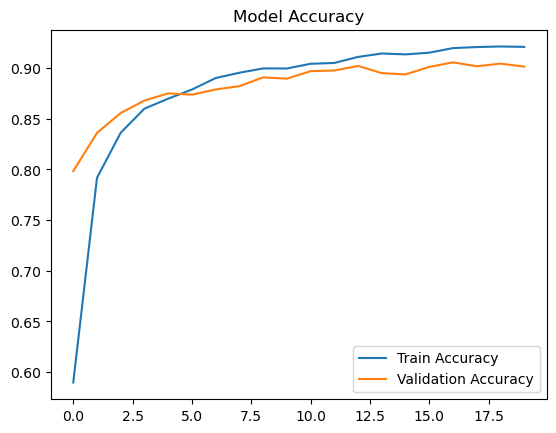

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()


## Waste Info Dictionary

In [36]:

waste_info = {
    "battery": {
        "type": "Hazardous",
        "category": "Hazardous",
        "recyclable": "Partially recyclable",
        "disposal": "Take to authorized e-waste or battery collection centers.",
        "tips": "Do not throw in household trash; avoid burning.",
        "impact": "Leaches heavy metals into soil and water if disposed improperly."
    },
    "biological": {
        "type": "Organic",
        "category": "Biodegradable",
        "recyclable": "Compostable",
        "disposal": "Use for composting or organic fertilizer.",
        "tips": "Separate from dry waste and avoid mixing with plastics.",
        "impact": "Produces methane in landfills if not composted, but enriches soil if composted."
    },
    "brown-glass": {
        "type": "Glass",
        "category": "Non-biodegradable",
        "recyclable": "Yes",
        "disposal": "Send to glass recycling centers.",
        "tips": "Reuse bottles and jars whenever possible.",
        "impact": "Broken glass causes injuries and persists in the environment for centuries."
    },
    "cardboard": {
        "type": "Paper",
        "category": "Biodegradable",
        "recyclable": "Yes",
        "disposal": "Flatten and send to recycling centers.",
        "tips": "Reuse boxes; avoid wetting before recycling.",
        "impact": "If not recycled, contributes to deforestation and landfill waste."
    },
    "clothes": {
        "type": "Textile",
        "category": "Non-biodegradable",
        "recyclable": "Partially recyclable",
        "disposal": "Donate usable clothes; recycle worn-out fabrics.",
        "tips": "Upcycle or donate clothes instead of throwing them.",
        "impact": "Textile waste contributes to landfill overflow and microplastic pollution."
    },
    "green-glass": {
        "type": "Glass",
        "category": "Non-biodegradable",
        "recyclable": "Yes",
        "disposal": "Send to glass recycling plants.",
        "tips": "Reuse containers; separate from other colored glass.",
        "impact": "Glass persists in the environment and can injure wildlife if discarded carelessly."
    },
    "metal": {
        "type": "Metal",
        "category": "Non-biodegradable",
        "recyclable": "Highly recyclable",
        "disposal": "Send to scrap metal dealers or metal recycling units.",
        "tips": "Separate cans and metal items from general waste.",
        "impact": "Metal production has high energy cost; recycling reduces environmental footprint."
    },
    "paper": {
        "type": "Paper",
        "category": "Biodegradable",
        "recyclable": "Yes",
        "disposal": "Recycle clean paper; avoid mixing with wet waste.",
        "tips": "Use both sides of paper; go digital when possible.",
        "impact": "Paper waste leads to deforestation and greenhouse gas emissions if not recycled."
    },
    "plastic": {
        "type": "Plastic",
        "category": "Non-biodegradable",
        "recyclable": "Partially recyclable",
        "disposal": "Send to plastic recycling centers or reuse for crafts.",
        "tips": "Avoid single-use plastics; use reusable bags and bottles.",
        "impact": "Plastic harms marine life and takes hundreds of years to decompose."
    },
    "shoes": {
        "type": "Textile/Plastic",
        "category": "Non-biodegradable",
        "recyclable": "Partially recyclable",
        "disposal": "Donate usable shoes; recycle material if possible.",
        "tips": "Buy durable shoes and avoid frequent disposal.",
        "impact": "Synthetic soles take decades to decompose in landfills."
    },
    "trash": {
        "type": "Mixed",
        "category": "Mixed / Non-biodegradable",
        "recyclable": "No",
        "disposal": "Send to municipal solid waste processing or landfill.",
        "tips": "Segregate wet and dry waste properly.",
        "impact": "Improper disposal pollutes land and water bodies."
    },
    "white-glass": {
        "type": "Glass",
        "category": "Non-biodegradable",
        "recyclable": "Yes",
        "disposal": "Send to glass recycling plants.",
        "tips": "Reuse clear glass bottles and jars.",
        "impact": "Glass persists in the environment; recycling saves raw materials."
    }
}

waste_info = {k.lower(): v for k, v in waste_info.items()}

## Test an Image & Display Prediction with Details

In [37]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

def test_waste_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Prediction
    prediction = model.predict(img_array)
    predicted_class = categories[np.argmax(prediction)]

    # Get waste info
    info = waste_info.get(predicted_class, {
        "category": "Unknown",
        "recyclable": "Unknown",
        "disposal": "No info available",
        "tips": "Dispose properly.",
        "impact": "No data available."
    })

    # Show the image
    plt.imshow(image.load_img(img_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}")
    plt.show()

    # Display details
    print(f"♻️ Waste Type: {predicted_class}")
    print(f"📂 Category: {info['category']}")
    print(f"🔁 Recyclable: {info['recyclable']}")
    print(f"🗑️ Disposal: {info['disposal']}")
    print(f"💡 Tip: {info['tips']}")
    print(f"🌍 Environmental Impact: {info['impact']}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


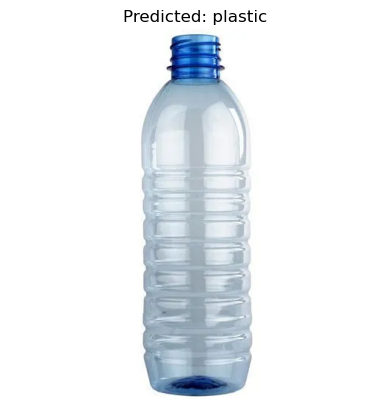

♻️ Waste Type: plastic
📂 Category: Non-biodegradable
🔁 Recyclable: Partially recyclable
🗑️ Disposal: Send to plastic recycling centers or reuse for crafts.
💡 Tip: Avoid single-use plastics; use reusable bags and bottles.
🌍 Environmental Impact: Plastic harms marine life and takes hundreds of years to decompose.


In [40]:
 test_waste_image(r"C:\Users\hp\Downloads\pet-bottle.webp")